Already written but in multiple scripts: training scripts, optuna, pairwise plots, 
lgb_reg_class_analysis.ipynb

In [1]:
# Import all pacakges
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.metrics import balanced_accuracy_score, precision_score, average_precision_score, roc_auc_score, recall_score, cohen_kappa_score, matthews_corrcoef, f1_score
import shap
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np



/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 25,35 mordred is the best so far - 65 is interesting
SEED = 15

# ds refers to the dataset used in model_training but will also work for 'baseline'
ds = "full_dataset"

plt.rcParams.update({'font.size': 15, 'grid.color': 'gray', 'grid.linestyle': '--'  })
colors = ["#F35965", "#6BF178", "#3EA7FF", "#8633A8", "#30D5C8", "#DC8DC4"]

smiles = pd.read_csv('../datasets/druglike_b3db_labelled_outerfolds.csv')['smiles']

true_ds = pd.read_csv('../datasets/druglike_b3db_labelled_outerfolds.csv')
pred_df = pd.read_csv(f'./custom_mtl_results/custom_mtl_predictions.csv')

# data_path = f'./results/training_output_values_{SEED}.csv'
data_path = f'./custom_mtl_results/custom_mtl_predictions.csv'

raw_results_df = pd.read_csv(data_path)
bbb_class = np.array(true_ds['bbb_class'])
logbb = np.array(true_ds['logBB'])

predicted_bbb_class = pred_df['predicted_bbb_class']
predicted_logBB = pred_df['predicted_logBB']

# all_preds = np.array(raw_results_df['all_preds'])
# all_trues_c = np.array(pred_df['predicted_bbb_class']) # logBB,bbb_class
# all_trues_r = np.array(pred_df['predicted_logBB'])
# averaged_predictions = np.mean(raw_results_df.iloc[:,6:], axis=1)

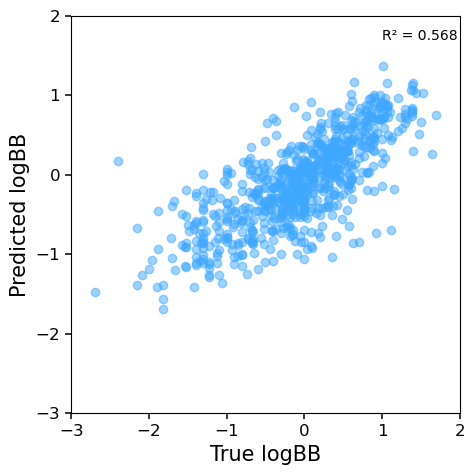

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5)) #, 
# axes = axes.flatten()  # flatten 2D array of axes for easy indexing


axes.scatter(logbb, predicted_logBB, color=colors[2], alpha=0.5)
axes.text(1, 1.70, f'R\u00B2 = 0.568', fontsize=10) # {metrics_df_test.iloc[5, 4]:.4f} ± {metrics_df_test.iloc[6, 4]:.4f}
axes.set_ylabel('Predicted logBB', fontsize=15)
axes.set_xlabel('True logBB', fontsize=15)
axes.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    width=1.1,
    length=4.5,
)
axes.set_xlim(-3,2)
axes.set_ylim(-3,2)
# axes.savefig('./evaluation_data/outerfold_predictions_experimental_predicted.png', dpi=300)

# axes[1].scatter(logbb,averaged_predictions, color=colors[2], alpha=0.5)
# axes[1].text(0, 1.75, f'R\u00B2 = {metrics_all_df.iloc[5, 4]:.4f} ± {metrics_all_df.iloc[6, 4]:.4f}', fontsize=10)
# axes[1].set_ylabel('Predicted logBB')
# axes[1].set_xlabel('True logBB')
# axes[1].set_xlim(-3,2)
# axes[1].set_ylim(-3,2)

fig.tight_layout()
fig.savefig(f'./training_hpt_plots_{SEED}_{ds}.png', dpi=600)
plt.show()


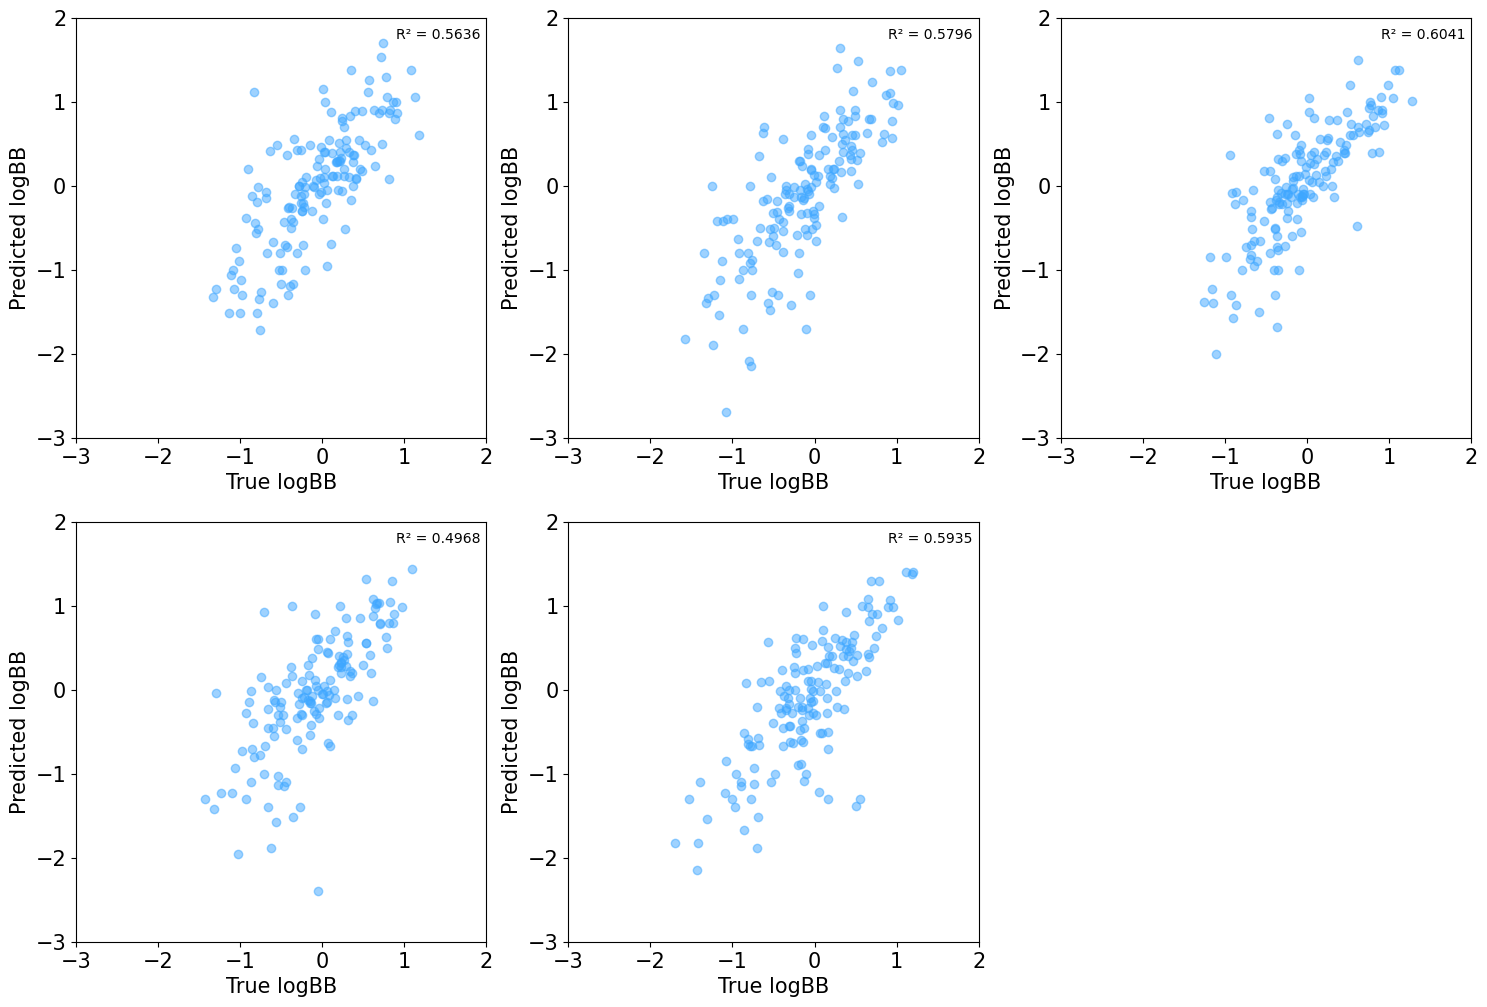

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()  # flatten 2D array of axes for easy indexing

metrics_per_fold_test_data_only = []

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
outer_fold = 1

count=-1
for train_idx, test_idx in outer_cv.split(all_preds, all_trues_c): 
    count += 1
    outer_fold=count+1
    ax = axes[count]

    cutoff = len(test_idx)

    y_test_c = all_trues_c[cutoff*(outer_fold-1):cutoff*(outer_fold)]
    y_test_r = all_trues_r[cutoff*(outer_fold-1):cutoff*(outer_fold)]
    y_test_pred = all_preds[cutoff*(outer_fold-1):cutoff*(outer_fold)]

    ax.scatter(y_test_pred, y_test_r, color=colors[2], alpha=0.5)
    ax.text(0.90, 1.75, f'R\u00B2 = {metrics_df_test.iloc[count, 4]:.4f}', fontsize=10)
    ax.set_ylabel('Predicted logBB')
    ax.set_xlabel('True logBB')
    ax.set_xlim(-3,2)
    ax.set_ylim(-3,2)

    # fig.tight_layout()
    # fig.savefig(f'../model_evaluation/{ds}/training_hpt_plots_{SEED}_{ds}.png', dpi=300)

    axes[5].set_axis_off()

# plt.savefig(f'../model_evaluation/{ds}/training_hpt_plots_individual_outerfolds_{SEED}_{ds}.png', dpi=300)
plt.show()




In [ ]:
metrics_per_fold_all_data_no_logbb = []

for outer_fold in range(5): 
    y_test_pred = np.array(raw_results_df[f'full_set_scores_fold_{outer_fold}'])
    y_test_r = logbb
    y_test_c = bbb_class
    y_test_c_no_logbb = y_test_c[np.isnan(y_test_r)]
    y_test_pred_no_logbb = y_test_pred[np.isnan(y_test_r)]

    balanced_acc = balanced_accuracy_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    prec = precision_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    recall = recall_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    rocauc = roc_auc_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    prauc = average_precision_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    kappa = cohen_kappa_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    mcc = matthews_corrcoef(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    f1 = f1_score(y_test_c_no_logbb, (y_test_pred_no_logbb<-1).astype(int))
    

    metrics_per_fold_all_data_no_logbb.append({"balanced_acc": balanced_acc, 
     "prec": prec, 
     "recall": recall, 
     "rocauc": rocauc, 
     "prauc": prauc, 
     "kappa": kappa, 
     "MCC": mcc, 
     "f1": f1})
    
metrics_all_df = pd.DataFrame(metrics_per_fold_all_data_no_logbb, index=[f'outerfold_{i}' for i in range(1,6)])
mean_row = pd.Series(np.mean(metrics_all_df, axis=0), name="mean")
std_row = pd.Series(np.std(metrics_all_df, axis=0), name="std")
metrics_all_df = pd.concat([metrics_all_df, mean_row.to_frame().T, std_row.to_frame().T])


# metrics_all_df.to_csv(f'../model_evaluation/{ds}/supp_figure_data_per_outerfold_all_data_no_logbb_{SEED}_{ds}.csv')

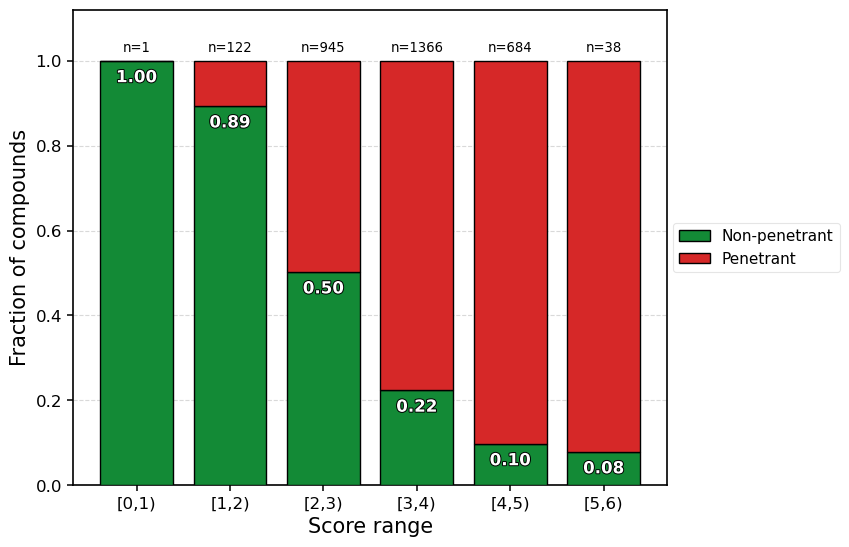

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# ---------------------------------------------------------
# Prism-like red/green stacked composition plot
# ---------------------------------------------------------

green_cb = "#138A36"
red_cb = "#D62828"

x = np.arange(len(bins) - 1)
bin_vals_array = np.asarray(bin_vals, dtype=float)

bin_support = np.array([
    np.sum(bin_indices == bin_index)
    for bin_index in range(1, len(bins))
])

fig, ax = plt.subplots(figsize=(8.8, 5.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Stacked bars
ax.bar(
    x,
    bin_vals_array,
    width=0.78,
    color=green_cb,
    edgecolor="black",
    linewidth=1.0,
    label="Non-penetrant",
    zorder=3,
)

ax.bar(
    x,
    1 - bin_vals_array,
    bottom=bin_vals_array,
    width=0.78,
    color=red_cb,
    edgecolor="black",
    linewidth=1.0,
    label="Penetrant",
    zorder=3,
)

label_loc = [0.95, 0.95, 0.91, 0.91, 0.6, 0.6]

# Ratio labels: always inside green region
for i, value in enumerate(bin_vals_array):
    if not np.isfinite(value):
        continue

    txt = ax.text(
        i,
        value -0.04, # * 0.55,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
        zorder=5,
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=1.4, foreground="black"),
        path_effects.Normal(),
    ])

    ax.text(
        i,
        1.015,
        f"n={bin_support[i]}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color="black",
    )

# Axes styling
ax.set_xlabel("Score range", fontsize=15)
ax.set_ylabel("Fraction of compounds", fontsize=15)

ax.set_xticks(
    x,
    labels=["[0,1)", "[1,2)", "[2,3)", "[3,4)", "[4,5)", "[5,6)"],
)

ax.set_ylim(0, 1.12)
ax.set_yticks(np.arange(0, 1.01, 0.2))

# Box around full plot
for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=12,
    width=1.1,
    length=4.5,
)

ax.grid(axis="y", linewidth=0.8, color="0.85", zorder=0)
ax.set_axisbelow(True)

# Legend to the side with light gray box
leg = ax.legend(
    frameon=True,
    fontsize=11,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    borderaxespad=0,
)

# leg.get_frame().set_facecolor("#F7F7F7")
leg.get_frame().set_edgecolor("#E5E5E5")
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_alpha(1.0)

fig.subplots_adjust(right=0.80, bottom=0.14, top=0.96)

plt.savefig("score_ranges_plot.png", dpi=600, bbox_inches="tight")
plt.show()

# Optional export:
# plt.savefig("score_ranges_plot.svg", bbox_inches="tight")
# plt.savefig("score_ranges_plot.pdf", bbox_inches="tight")


Bin 0-1: mean class_val = 1.000
Bin 1-2: mean class_val = 0.893
Bin 2-3: mean class_val = 0.503
Bin 3-4: mean class_val = 0.224
Bin 4-5: mean class_val = 0.098
Bin 5-6: mean class_val = 0.079
{'balanced_acc_bins': [1.0, 0.5, 0.5857110862262038, 0.5, 0.5, 0.5], 'recall_bins': [1.0, 1.0, 0.2863157894736842, 0.0, 0.0, 0.0], 'prec_bins': [1.0, 0.8934426229508197, 0.7157894736842105, 0.0, 0.0, 0.0], 'f1_bins': [1.0, 0.9437229437229437, 0.40902255639097745, 0.0, 0.0, 0.0], 'rocauc_bins': [nan, 0.5, 0.5857110862262038, 0.5, 0.5, 0.5], 'prauc_bins': [1.0, 0.8934426229508197, 0.5636719869850064, 0.2240117130307467, 0.097953216374269, 0.07894736842105263], 'kappa_bins': [nan, 0.0, 0.17087682089635536, 0.0, 0.0, 0.0], 'mcc_bins': [0.0, 0.0, 0.21385157450953365, 0.0, 0.0, 0.0], 'support_c_bins': [1, 122, 945, 1366, 684, 38], 'mae_bins': [nan, 0.39877111075085103, 0.4753259899440635, 0.3550392945325021, 0.2997330397956745, 0.2545397400694007], 'mde_bins': [nan, 0.30151372040965163, 0.39933949157685

/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/sklearn/metrics/_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was fo

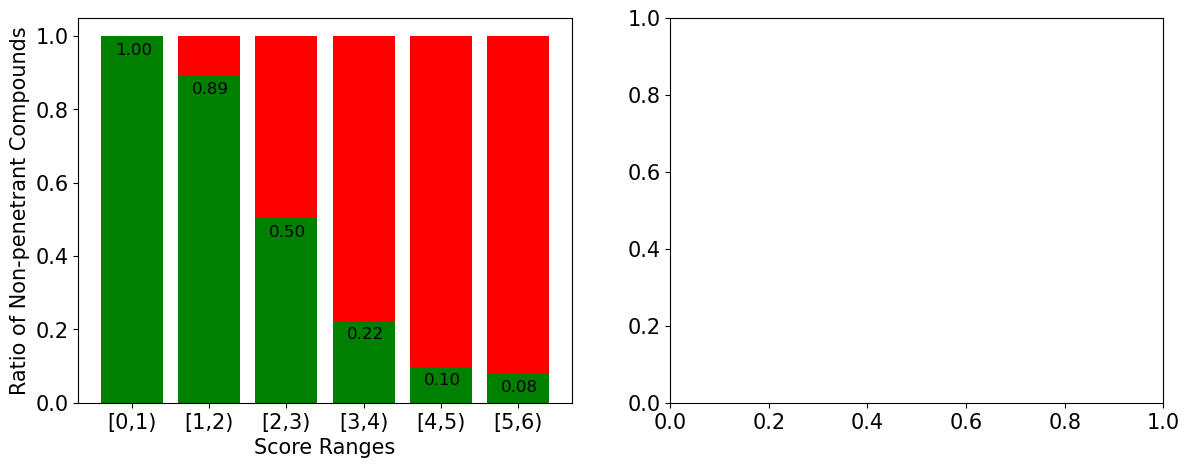

In [45]:
# Determine classificaiton and regression at different score ranges: 

scaler = MinMaxScaler()
scaler.fit(np.array([-2.7, 1, 1.7]).reshape(-1, 1))
y_pred_norm = scaler.transform(np.array(predicted_logBB).reshape(-1, 1)).flatten()
final_score = y_pred_norm*6

all_vals = final_score

bin_vals=[]
bins = np.arange(0,7,1)
bin_indices = np.digitize(all_vals, bins, right=False)
for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        avg = np.array(bbb_class)[in_bin].mean()
        bin_vals.append(avg)
        print(f"Bin {bins[i-1]}-{bins[i]}: mean class_val = {avg:.3f}")
    else: 
        print(f"Bin {bins[i-1]}-{bins[i]}: mean class_val = NA")
        bin_vals.append(np.nan)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
axes = axes.flatten()  # flatten 2D array of axes for easy indexing

axes[0].bar(list(bins)[:-1], [1,1,1,1,1,1], color='red')
axes[0].bar(list(bins)[:-1], bin_vals, color='green')
for b_id, bin in enumerate(list(bins)[:-1]): 
    axes[0].text(bin-0.22, bin_vals[b_id]-0.05, f'{bin_vals[b_id]:.2f}', fontdict={'fontsize':12} )
# axes[0].text(5-0.22, 0.01, f'{bin_vals[5]:.2f}',fontdict={'fontsize':12}  )
axes[0].set_xlabel('Score Ranges')
axes[0].set_ylabel('Ratio of Non-penetrant Compounds')
axes[0].set_xticks(ticks=list(bins)[:-1], labels=['[0,1)', '[1,2)', '[2,3)', '[3,4)', '[4,5)', '[5,6)']) #, fontdict={'fontsize':13}
# axes[0].savefig(f'../model_evaluation/{ds}/score_ratios_outerfold_test_data_only_{SEED}_{ds}.png')

# plt.close()


mse_bins, mde_bins, mae_bins, pearson_bins, r2_bins, support_r_bins = [],[],[],[],[],[]
balanced_acc_bins, prec_bins, recall_bins, rocauc_bins, prauc_bins, kappa_bins, mcc_bins, f1_bins, support_c_bins = [],[],[],[],[],[],[],[],[]
balanced_acc_bins_neg, prec_bins_neg, recall_bins_neg, rocauc_bins_neg, prauc_bins_neg, kappa_bins_neg, mcc_bins_neg, f1_bins_neg, support_c_bins_neg = [],[],[],[],[],[],[],[],[]



for bin_index in range(1,7):

    mask = bin_indices == bin_index

    trues_c_at_this_index = np.asarray(bbb_class)[mask]
    trues_r_at_this_index = np.asarray(logbb)[mask]
    preds_r_at_this_index = predicted_logBB.to_numpy()[mask]
    preds_c_at_this_index = (preds_r_at_this_index < -1).astype(int)

    # trues_c_at_this_index = np.array(bbb_class)[np.where(bin_indices==bin_index)]
    # trues_r_at_this_index = logbb[np.where(bin_indices==bin_index)]
    # preds_r_at_this_index = predicted_logBB[np.where(bin_indices==bin_index)]
    # preds_c_at_this_index = (preds_r_at_this_index < -1).astype(int)

    
    support_r_bins.append(len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
    if len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]) > 0: 
        mse_bins.append(mean_squared_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        mde_bins.append(median_absolute_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        mae_bins.append(mean_absolute_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        if len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]) > 1: 
            pearson_bins.append(pearsonr(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)])[0])
            r2_bins.append(r2_score(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        else: 
            pearson_bins.append(np.nan)  
            r2_bins.append(np.nan)  
    else: 
        mse_bins.append(np.nan)
        mde_bins.append(np.nan)  
        mae_bins.append(np.nan)  
        pearson_bins.append(np.nan)  
        r2_bins.append(np.nan)  

    
    balanced_acc_bins.append(balanced_accuracy_score(trues_c_at_this_index, preds_c_at_this_index))
    prec_bins.append(precision_score(trues_c_at_this_index, preds_c_at_this_index))
    recall_bins.append(recall_score(trues_c_at_this_index, preds_c_at_this_index))
    
    kappa_bins.append(cohen_kappa_score(trues_c_at_this_index, preds_c_at_this_index))
    mcc_bins.append(matthews_corrcoef(trues_c_at_this_index, preds_c_at_this_index))
    f1_bins.append(f1_score(trues_c_at_this_index, preds_c_at_this_index))
    support_c_bins.append(len(trues_c_at_this_index))

    if len(preds_c_at_this_index) > 0: 
        rocauc_bins.append(roc_auc_score(trues_c_at_this_index, preds_c_at_this_index))
        prauc_bins.append(average_precision_score(trues_c_at_this_index, preds_c_at_this_index))
    else: 
        rocauc_bins.append(np.nan)
        prauc_bins.append(np.nan)


    balanced_acc_bins_neg.append(balanced_accuracy_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    prec_bins_neg.append(precision_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    recall_bins_neg.append(recall_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    kappa_bins_neg.append(cohen_kappa_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    mcc_bins_neg.append(matthews_corrcoef((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    f1_bins_neg.append(f1_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    support_c_bins_neg.append(len(trues_c_at_this_index))

    if len(preds_c_at_this_index) > 0: 
        rocauc_bins_neg.append(roc_auc_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
        prauc_bins_neg.append(average_precision_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    else: 
        rocauc_bins_neg.append(np.nan)
        prauc_bins_neg.append(np.nan)

bin_data = {'balanced_acc_bins': balanced_acc_bins, 'recall_bins': recall_bins, 'prec_bins':prec_bins, 'f1_bins': f1_bins, \
            'rocauc_bins':rocauc_bins, 'prauc_bins': prauc_bins, 'kappa_bins': kappa_bins, 'mcc_bins': mcc_bins, 'support_c_bins': support_c_bins, \
            'mae_bins': mae_bins, 'mde_bins': mde_bins, 'mse_bins': mse_bins, 'pearson_bins': pearson_bins, 'r2_bins': r2_bins, 'support_r_bins': support_r_bins, 
            'balanced_acc_bins_neg': balanced_acc_bins_neg, 'prec_bins_neg': prec_bins_neg, 'recall_bins_neg': recall_bins_neg, 'rocauc_bins_neg': rocauc_bins_neg, \
            'prauc_bins_neg': prauc_bins_neg, 'kappa_bins_neg': kappa_bins_neg, 'mcc_bins_neg': mcc_bins_neg, 'f1_bins_neg': f1_bins_neg, 'support_c_bins_neg': support_c_bins_neg}

print(bin_data)

bins_data_df = pd.DataFrame(data=bin_data)
print(bins_data_df)
bins_data_df.to_csv(f'./results/bins.csv')



In [ ]:


averaged_predictions_arr = np.array(averaged_predictions)
y_pred_norm_averaged = scaler.transform(averaged_predictions_arr.reshape(-1, 1)).flatten()
final_score_averaged = y_pred_norm_averaged*6
all_vals_averaged = final_score_averaged

bin_vals=[]
bins = np.arange(0,7,1)
bin_indices_averaged = np.digitize(all_vals_averaged, bins, right=False)
for i in range(1, len(bins)):
    in_bin = bin_indices_averaged == i
    if np.any(in_bin):
        avg = np.array(bbb_class)[in_bin].mean()
        bin_vals.append(avg)
        print(f"Bin {bins[i-1]}-{bins[i]}: mean class_val = {avg:.3f}")
    else: 
        print(f"Bin {bins[i-1]}-{bins[i]}: mean class_val = NA")
        bin_vals.append(np.nan)

axes[1].bar(list(bins)[:-1], [1,1,1,1,1,1], color='red')
axes[1].bar(list(bins)[:-1], bin_vals, color='green')
for b_id, bin in enumerate(list(bins)[:-2]): 
    axes[1].text(bin-0.22, bin_vals[b_id]-0.05, f'{bin_vals[b_id]:.2f}', fontdict={'fontsize':12})
axes[1].text(5-0.22, 0.005, f'{bin_vals[5]:.2f}', fontdict={'fontsize':12})
axes[1].set_xlabel('Score Ranges')
axes[1].set_xticks(ticks=list(bins)[:-1], labels=['[0,1)', '[1,2)', '[2,3)', '[3,4)', '[4,5)', '[5,6)'])




mse_bins, mde_bins, mae_bins, pearson_bins, r2_bins, support_r_bins = [],[],[],[],[],[]
balanced_acc_bins, prec_bins, recall_bins, rocauc_bins, prauc_bins, kappa_bins, mcc_bins, f1_bins, support_c_bins = [],[],[],[],[],[],[],[],[]
balanced_acc_bins_neg, prec_bins_neg, recall_bins_neg, rocauc_bins_neg, prauc_bins_neg, kappa_bins_neg, mcc_bins_neg, f1_bins_neg, support_c_bins_neg = [],[],[],[],[],[],[],[],[]



for bin_index in range(1,7):

    trues_c_at_this_index = np.array(all_trues_c)[np.where(bin_indices==bin_index)]
    trues_r_at_this_index = all_trues_r[np.where(bin_indices==bin_index)]
    preds_r_at_this_index = averaged_predictions_arr[np.where(bin_indices==bin_index)]
    preds_c_at_this_index = (preds_r_at_this_index < -1).astype(int)

    
    support_r_bins.append(len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
    if len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]) > 0: 
        mse_bins.append(mean_squared_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        mde_bins.append(median_absolute_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        mae_bins.append(mean_absolute_error(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        if len(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)]) > 1: 
            pearson_bins.append(pearsonr(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)])[0])
            r2_bins.append(r2_score(trues_r_at_this_index[~np.isnan(trues_r_at_this_index)], preds_r_at_this_index[~np.isnan(trues_r_at_this_index)]))
        else: 
            pearson_bins.append(np.nan)  
            r2_bins.append(np.nan)  
    else: 
        mse_bins.append(np.nan)
        mde_bins.append(np.nan)  
        mae_bins.append(np.nan)  
        pearson_bins.append(np.nan)  
        r2_bins.append(np.nan)  

    
    balanced_acc_bins.append(balanced_accuracy_score(trues_c_at_this_index, preds_c_at_this_index))
    prec_bins.append(precision_score(trues_c_at_this_index, preds_c_at_this_index))
    recall_bins.append(recall_score(trues_c_at_this_index, preds_c_at_this_index))
    
    kappa_bins.append(cohen_kappa_score(trues_c_at_this_index, preds_c_at_this_index))
    mcc_bins.append(matthews_corrcoef(trues_c_at_this_index, preds_c_at_this_index))
    f1_bins.append(f1_score(trues_c_at_this_index, preds_c_at_this_index))
    support_c_bins.append(len(trues_c_at_this_index))

    if len(preds_c_at_this_index) > 0: 
        rocauc_bins.append(roc_auc_score(trues_c_at_this_index, preds_c_at_this_index))
        prauc_bins.append(average_precision_score(trues_c_at_this_index, preds_c_at_this_index))
    else: 
        rocauc_bins.append(np.nan)
        prauc_bins.append(np.nan)


    balanced_acc_bins_neg.append(balanced_accuracy_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    prec_bins_neg.append(precision_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    recall_bins_neg.append(recall_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    kappa_bins_neg.append(cohen_kappa_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    mcc_bins_neg.append(matthews_corrcoef((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    f1_bins_neg.append(f1_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    support_c_bins_neg.append(len(trues_c_at_this_index))

    if len(preds_c_at_this_index) > 0: 
        rocauc_bins_neg.append(roc_auc_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
        prauc_bins_neg.append(average_precision_score((1-trues_c_at_this_index), (1-preds_c_at_this_index)))
    else: 
        rocauc_bins_neg.append(np.nan)
        prauc_bins_neg.append(np.nan)

bin_data = {'balanced_acc_bins': balanced_acc_bins, 'recall_bins': recall_bins, 'prec_bins':prec_bins, 'f1_bins': f1_bins, \
            'rocauc_bins':rocauc_bins, 'prauc_bins': prauc_bins, 'kappa_bins': kappa_bins, 'mcc_bins': mcc_bins, 'support_c_bins': support_c_bins, \
            'mae_bins': mae_bins, 'mde_bins': mde_bins, 'mse_bins': mse_bins, 'pearson_bins': pearson_bins, 'r2_bins': r2_bins, 'support_r_bins': support_r_bins, 
            'balanced_acc_bins_neg': balanced_acc_bins_neg, 'prec_bins_neg': prec_bins_neg, 'recall_bins_neg': recall_bins_neg, 'rocauc_bins_neg': rocauc_bins_neg, \
            'prauc_bins_neg': prauc_bins_neg, 'kappa_bins_neg': kappa_bins_neg, 'mcc_bins_neg': mcc_bins_neg, 'f1_bins_neg': f1_bins_neg, 'support_c_bins_neg': support_c_bins_neg}

print(bin_data)

bins_data_df = pd.DataFrame(data=bin_data)
print(bins_data_df)
# bins_data_df.to_csv(f'../model_evaluation/{ds}/per_bin_performance_all_data_{SEED}_{ds}.csv')

# plt.savefig(f'../model_evaluation/{ds}/score_performance_test_all.png', dpi=300)
plt.show()

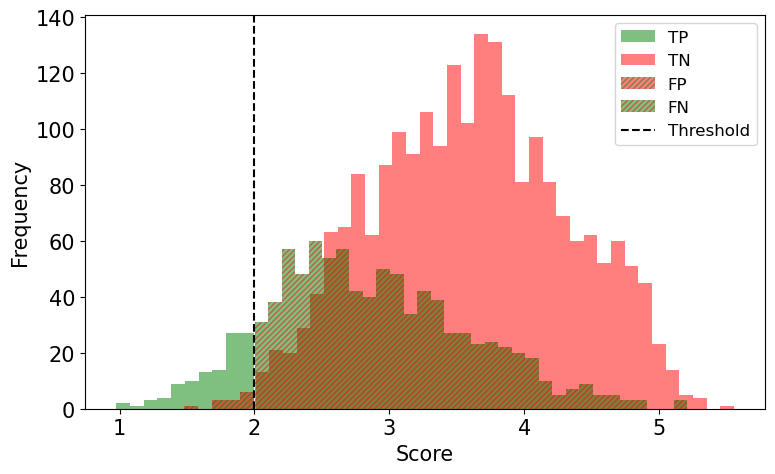

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson
from scipy.stats import gaussian_kde

class0 = final_score[bbb_class ==0] # (BBB penetrant)
class1 = final_score[bbb_class ==1] # (BBB non-penetrant)

kde0 = gaussian_kde(class0)
kde1 = gaussian_kde(class1)

plt.figure(figsize=(8, 5))

x = np.linspace(0, 6, 500)


def num_from_width(data, binwidth=0.1):
    data_range = np.max(data)-np.min(data)
    num_bins = int(data_range/binwidth)

    return num_bins

plt.hist(class1[class1 < 2], bins=num_from_width(class1[class1 < 2]), density=False, alpha=0.5,
         color='green', label='TP')
plt.hist(class0[class0 >= 2], bins=num_from_width(class0[class0 >= 2]), density=False, alpha=0.5,
         color='red', label='TN')
plt.hist(class0[class0 < 2], bins=num_from_width(class0[class0 < 2]), density=False, alpha=0.5,
          facecolor='red', hatch='//////', edgecolor='green', linewidth=0.0, label='FP')
plt.hist(class1[class1 >= 2], bins=num_from_width(class1[class1 >= 2]), density=False, alpha=0.5,
          facecolor='green', hatch='//////', edgecolor='red', linewidth=0.0, label='FN')


threshold = 2

plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend(fontsize=12)                        
plt.tight_layout()

# plt.savefig(f'../model_evaluation/{ds}/historgram_tptnfpfn_{SEED}_{ds}.png', dpi=300)
plt.show()



In [27]:
predicted_bbb_class[bbb_class==0]


87      0
88      1
89      0
90      0
91      0
       ..
3083    0
3091    0
3112    0
3113    0
3116    0
Name: predicted_bbb_class, Length: 2123, dtype: int64

In [23]:
bbb_class

array([1, 1, 1, ..., 1, 1, 0])